# Diemtigen – Interpretation Notebook (Ante-hoc / Glass-box) 
This notebook is dedicated to **interpretation** of the best-performing settings from `02_train_eval.ipynb`. 
We focus on **native interpretability** (ante-hoc), not post-hoc explainers: - **Logistic Regression (L1)** → coefficients $\beta_i$ (log-odds contributions)
- **EBM** → additive shape functions $f_i(x_i)$ + global importances > Recommended workflow:
1. Run `02_train_eval.ipynb` to choose the best **representation** (split / spec / hybrid) and **model**.
2. Come here to produce **paper-ready plots** and stable interpretations. 
--- 
## Mathematical interpretation objects 
### Logistic Regression (L1)
$$
\text{logit}(p)=\beta_0 + \sum_i \beta_i x_i \quad\Rightarrow\quad
\frac{\partial \text{logit}(p)}{\partial x_i}=\beta_i
$$
- sign($\beta_i$) tells direction (toward aftershock if positive, foreshock if negative)
- $|\beta_i|$ tells strength (in standardized units if inputs are z-scored) 
### EBM
$$
\text{logit}(p)=\beta_0+\sum_i f_i(x_i)
$$
- plot $f_i(x)$: shows how changing feature $x_i$ affects the log-odds
- additive structure makes it **directly interpretable** 
--- 
## Segment-aware feature grouping (split-features)
For split features, columns follow the pattern:
- `{COMP}_{SEG}_...` where `SEG ∈ {noise, p, coda}`
- ratios: `*_snr_*`, `*_coda_over_p_*`, `ZHratio_*` We will group plots by:
- segment: noise / p / coda / ratios
- channel: E / N / Z

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from interpret.glassbox import ExplainableBoostingClassifier

In [16]:
# Load data representations
root_dir = Path("diemtigen_data")
df_feat = pd.read_csv(root_dir / "data_features.csv")
df_spec = pd.read_csv(root_dir / "data_lowresspec.csv")

meta_cols = ["event_id", "label", "event_type", "sampling_rate", "npts"]
spec_only_cols = [c for c in df_spec.columns if c not in meta_cols]
df_hybrid = df_feat.merge(df_spec[["event_id"] + spec_only_cols], on="event_id", how="inner")

datasets = {
    "split_features": df_feat,
    "lowres_spec": df_spec,
    "hybrid": df_hybrid,
}

{k: v.shape for k, v in datasets.items()}

{'split_features': (2341, 143),
 'lowres_spec': (2341, 185),
 'hybrid': (2341, 323)}

In [17]:
def split_xy(df):
    y = df["label"].astype(int).values
    X = df.drop(columns=["label", "event_type"]).copy()
    ids = X["event_id"].astype(str).values
    X = X.drop(columns=["event_id"])
    return X, y, ids

def make_logreg_l1(C=1.0):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l1", solver="saga", C=C, max_iter=5000, n_jobs=-1, class_weight="balanced"
        ))
    ])

def make_ebm(interactions=0):
    return ExplainableBoostingClassifier(
        random_state=0,
        interactions=interactions,   # keep 0 for pure additive
    )

### Choose what to interpret
 Set `repr_choice` and `model_choice` according to the best results from `02_train_eval.ipynb`. 
- `repr_choice` ∈ {`split_features`, `lowres_spec`, `hybrid`}
- `model_choice` ∈ {`LogReg_L1`, `EBM_additive`, ``}

In [18]:
repr_choice = "split_features"
model_choice = "EBM_additive"  

df = datasets[repr_choice]
X, y, ids = split_xy(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

X_train.shape, X_test.shape

((1872, 140), (469, 140))

In [19]:
# Train selected model
if model_choice == "LogReg_L1":
    model = make_logreg_l1(C=1.0)
    model.fit(X_train, y_train)

else:  # EBM_additive
    model = make_ebm(interactions=0)
    model.fit(X_train, y_train)

model

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,0
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


## 1) Logistic Regression interpretation (coefficients) 
We plot the largest-magnitude coefficients.
If inputs are standardized, $\beta_i$ indicates the effect per **1 standard deviation** increase in feature $x_i$.

In [ ]:
def plot_top_logreg_coeffs(pipe, feature_names, topk=30, title="Top LogReg coefficients"):
    clf = pipe.named_steps["clf"]
    coef = clf.coef_.ravel()
    idx = np.argsort(np.abs(coef))[::-1][:topk]
    feats = [feature_names[i] for i in idx]
    vals = coef[idx]

    plt.figure(figsize=(10, max(4, topk*0.25)))
    y_pos = np.arange(len(idx))
    plt.barh(y_pos, vals)
    plt.yticks(y_pos, feats)
    plt.gca().invert_yaxis()
    plt.axvline(0, linewidth=1)
    plt.title(title)
    plt.xlabel("Coefficient (log-odds per 1 SD)")
    plt.tight_layout()
    plt.show()

if model_choice == "LogReg_L1":
    plot_top_logreg_coeffs(model, X_train.columns.to_list(), topk=30,
                           title=f"Top coefficients – {repr_choice}")
else:
    print("Set model_choice='LogReg_L1' to run this cell.")

# 2) EBM interpretation (global importance + shape functions) 
EBM provides:
- **global feature importances** (native)
- **shape functions** $f_i(x)$ for each feature We show:
1) Top importances table
2) Shape plots for the top-K features

In [20]:
def ebm_top_importances(ebm, feature_names=None, topk=20):
    global_exp = ebm.explain_global()
    data = global_exp.data()

    names = data["names"]
    scores = np.array(data["scores"], dtype=float)

    imp_df = pd.DataFrame({
        "feature": names,
        "importance": scores
    }).sort_values("importance", ascending=False)

    return imp_df.head(topk).reset_index(drop=True)

if model_choice.startswith("EBM"):
    top_imp = ebm_top_importances(model, topk=25)
    top_imp
else:
    print("Set model_choice='EBM_additive' to run this cell.")

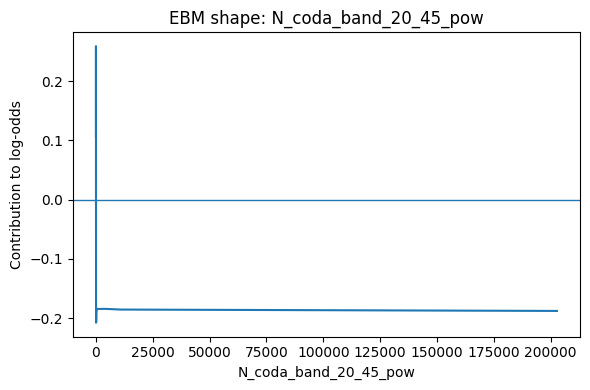

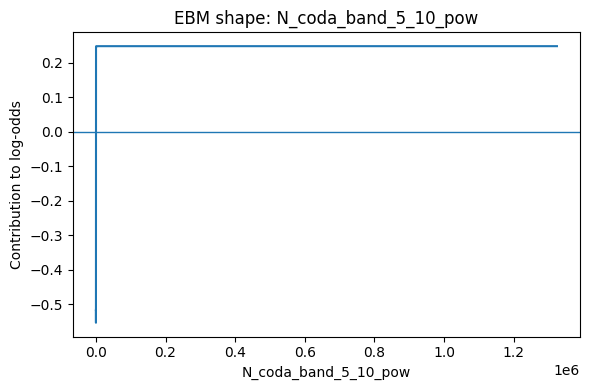

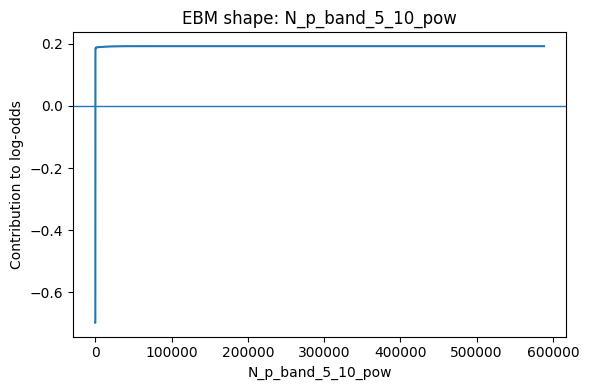

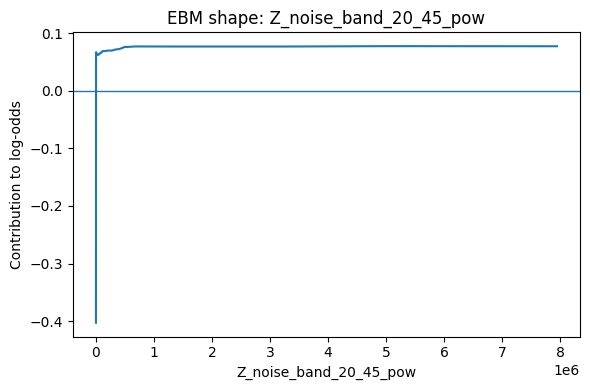

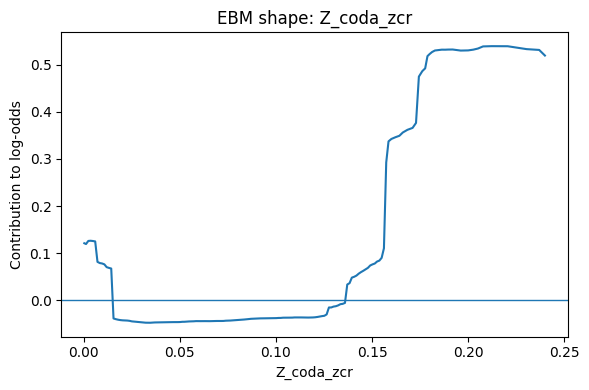

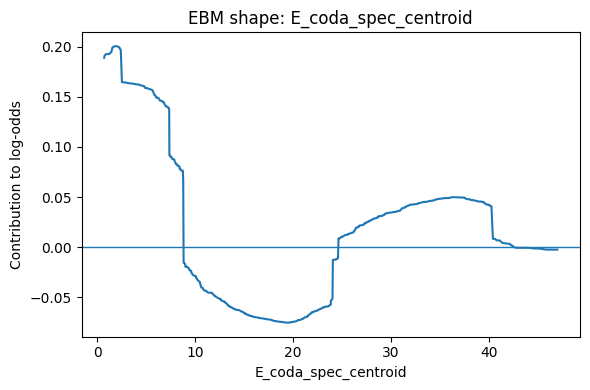

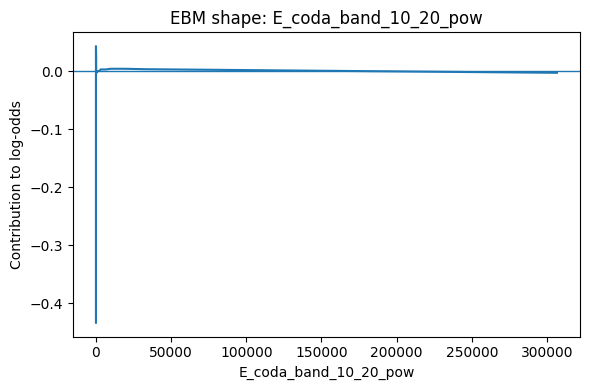

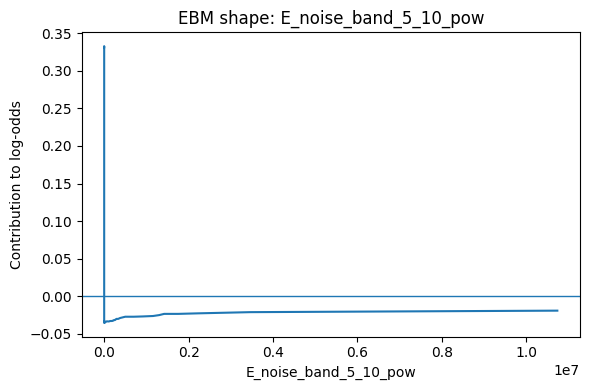

In [21]:
def plot_ebm_shape(ebm, feature_index, feature_name):
    exp = ebm.explain_global()
    data = exp.data(feature_index)

    xs = data.get("names")
    ys = data.get("scores")

    if xs is None or ys is None:
        print("No shape data found for", feature_name)
        return

    ys = np.array(ys, dtype=float)

    # Try to convert x labels to numeric
    try:
        xs_num = np.array(xs, dtype=float)
    except Exception:
        xs_num = np.arange(len(xs))

    # EBM often returns one more x label than score (bin edges vs bin values)
    if len(xs_num) == len(ys) + 1:
        xs_plot = 0.5 * (xs_num[:-1] + xs_num[1:])   # bin centers
    elif len(xs_num) == len(ys):
        xs_plot = xs_num
    else:
        # fallback: use simple index positions
        xs_plot = np.arange(len(ys))

    plt.figure(figsize=(6, 4))
    plt.plot(xs_plot, ys)
    plt.title(f"EBM shape: {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Contribution to log-odds")
    plt.axhline(0, linewidth=1)
    plt.tight_layout()
    plt.show()


if model_choice.startswith("EBM"):
    feature_names = X_train.columns.to_list()
    top_features = top_imp["feature"].head(8).tolist()

    for fn in top_features:
        fi = feature_names.index(fn)
        plot_ebm_shape(model, fi, fn)
else:
    print("Set model_choice='EBM_additive' to run this cell.")

### Segment-aware grouping (split_features) If `repr_choice = split_features`, we can automatically group features by segment and channel and create summary tables.

In [22]:
import re

def group_feature(name: str):
    # segment patterns
    if "_noise_" in name: seg = "noise"
    elif "_p_" in name: seg = "p"
    elif "_coda_" in name: seg = "coda"
    elif "ZHratio_" in name or "_snr_" in name or "_coda_over_p_" in name:
        seg = "ratios"
    else:
        seg = "other"

    # channel patterns
    if name.startswith("E_"): ch = "E"
    elif name.startswith("N_"): ch = "N"
    elif name.startswith("Z_"): ch = "Z"
    elif name.startswith("H_"): ch = "H"
    elif name.startswith("ZHratio_"): ch = "Z/H"
    else:
        ch = "meta"

    return seg, ch

def add_groups(df_imp):
    segs, chs = zip(*[group_feature(f) for f in df_imp["feature"]])
    out = df_imp.copy()
    out["segment"] = segs
    out["channel"] = chs
    return out

if model_choice.startswith("EBM") and repr_choice == "split_features":
    grouped = add_groups(top_imp)
    grouped
else:
    print("Run with repr_choice='split_features' and model_choice='EBM_additive' to use grouping.")

Importance by segment:


segment
coda     1.338773
p        0.773266
noise    0.772688
other    0.000000
Name: importance, dtype: float64


Importance by channel:


channel
N       1.117013
E       0.866032
Z       0.840570
Z/H     0.061111
meta    0.000000
Name: importance, dtype: float64

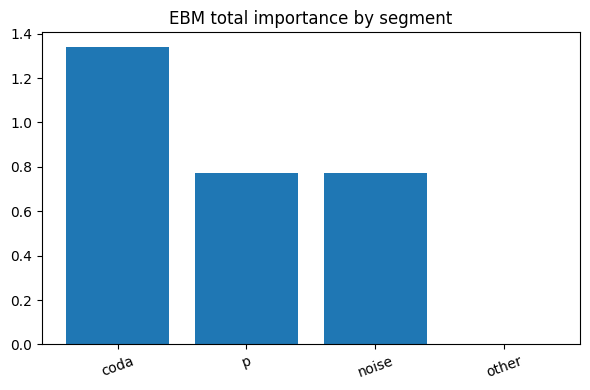

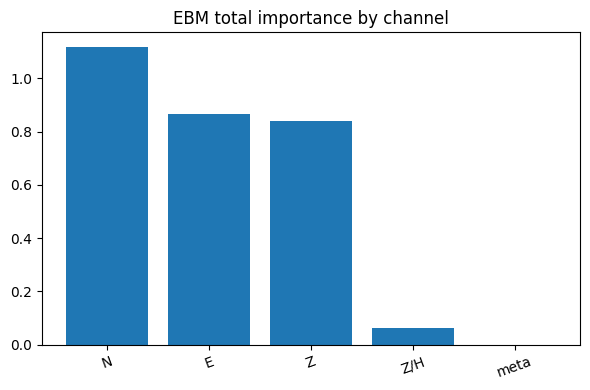

In [23]:
# Aggregate importance by segment/channel (EBM)
if model_choice.startswith("EBM") and repr_choice == "split_features":
    grouped = add_groups(ebm_top_importances(model, X_train.columns.to_list(), topk=min(200, X_train.shape[1])))
    seg_sum = grouped.groupby("segment")["importance"].sum().sort_values(ascending=False)
    ch_sum = grouped.groupby("channel")["importance"].sum().sort_values(ascending=False)

    print("Importance by segment:")
    display(seg_sum)
    print("\nImportance by channel:")
    display(ch_sum)

    # bar plots
    plt.figure(figsize=(6,4))
    plt.bar(seg_sum.index, seg_sum.values)
    plt.title("EBM total importance by segment")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.bar(ch_sum.index, ch_sum.values)
    plt.title("EBM total importance by channel")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("Run with repr_choice='split_features' and model_choice='EBM_additive'.")

## Stability analysis 
To avoid “one-split” artifacts, we repeat training over multiple random splits and check whether top features remain stable. We compute, for EBM:
- top-K features per split
- frequency of appearance across splits (You can extend this to coefficients for LogReg.)

In [ ]:
from collections import Counter

def stability_ebm_top_features(df, topk=20, n_runs=20, test_size=0.2, random_seed=0):
    X, y, _ = split_xy(df)
    counts = Counter()

    for i in range(n_runs):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_seed + i, stratify=y
        )

        ebm = make_ebm(interactions=0)
        ebm.fit(X_train, y_train)

        global_exp = ebm.explain_global()
        data = global_exp.data()

        names = data["names"]
        scores = np.array(data["scores"], dtype=float)

        order = np.argsort(scores)[::-1][:topk]
        for idx in order:
            counts[names[idx]] += 1

    out = pd.DataFrame({
        "feature": list(counts.keys()),
        "count": list(counts.values())
    })

    out["freq"] = out["count"] / float(n_runs)
    out = out.sort_values(["freq", "count"], ascending=False).reset_index(drop=True)
    return out

if repr_choice == "split_features":
    stab = stability_ebm_top_features(datasets[repr_choice], topk=20, n_runs=25)
    stab.head(30)

In [ ]:
# Plot stability (top 20)
if repr_choice == "split_features":
    top = stab.head(20).iloc[::-1]
    plt.figure(figsize=(10,6))
    plt.barh(top["feature"], top["freq"])
    plt.title("EBM top-feature stability across random splits (freq)")
    plt.xlabel("Frequency of appearing in top-20")
    plt.tight_layout()
    plt.show()